# Model Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [8]:
RED = "#ef7a78"
GREEN = "#68C5B3"
# Load evaluation results
file_name = "_Evals_Results_SIT_Mar-07_1903"
CSV_PATH = f"../results/{file_name}.csv"
POOR_THRESHOLD = 0.6

df = pd.read_csv(CSV_PATH)
rf = df[df["Algorithm"] == "REINFORCE"].copy()

# Deduplicate: keep one row per (Model File, Training File, Test File) combo
# Multiple rounds produce identical scores – use mean per unique combo
rf_dedup = rf.groupby(["Model File", "Attention Mechanism", "Training File", "Test File"], as_index=False)["Eval_Score"].mean()

print(f"Total REINFORCE unique evaluations : {len(rf_dedup)}")
print(f"Poor performing (Eval_Score < {POOR_THRESHOLD}): {(rf_dedup['Eval_Score'] < POOR_THRESHOLD).sum()}")
rf_dedup.head(3)


Total REINFORCE unique evaluations : 36
Poor performing (Eval_Score < 0.4): 16


,Model File,Attention Mechanism,Training File,Test File,Eval_Score
0,REINFORCE_MH_SIT_17_500_1e-04_99_07-03-18-47,Multi-Head,SIT_17,SIT_17,0.261895
1,REINFORCE_MH_SIT_17_500_1e-04_99_07-03-18-47,Multi-Head,SIT_17,SIT_19,0.956487
2,REINFORCE_MH_SIT_17_500_1e-04_99_07-03-18-47,Multi-Head,SIT_17,SIT_9,0.918825


## Angle 1 — Attention Mechanism
- Is there an attention mechanism whose average Eval_Score drags REINFORCE below 0.4?

Overall REINFORCE Avg Eval_Score : 0.6451

Attention Mechanism  Avg_Score  Poor_Count  Total  Poor_Rate_%
           Temporal   0.262715           9      9        100.0
     Self-Attention   0.722123           3      9         33.3
    Nadaraya-Watson   0.723018           3      9         33.3
         Multi-Head   0.872370           1      9         11.1

>>> Attention mechanisms BELOW overall average (0.6451): ['Temporal']


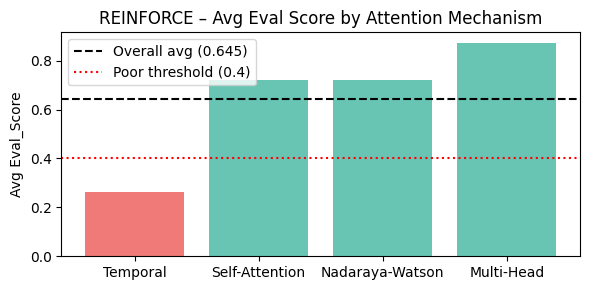

In [9]:
## Angle 1 — Attention Mechanism
# Is there an attention mechanism whose average Eval_Score drags REINFORCE below 0.4?

# Per-attention-mechanism: avg score and poor-rate
attn_stats = rf_dedup.groupby("Attention Mechanism")["Eval_Score"].agg(
    Avg_Score="mean",
    Poor_Count=lambda s: (s < POOR_THRESHOLD).sum(),
    Total="count"
).reset_index()
attn_stats["Poor_Rate_%"] = (attn_stats["Poor_Count"] / attn_stats["Total"] * 100).round(1)
attn_stats = attn_stats.sort_values("Avg_Score")

overall_avg = rf_dedup["Eval_Score"].mean()
print(f"Overall REINFORCE Avg Eval_Score : {overall_avg:.4f}")
print()
print(attn_stats.to_string(index=False))

# Flag attention mechanisms whose avg score is below the overall average
poor_attn = attn_stats[attn_stats["Avg_Score"] < overall_avg]["Attention Mechanism"].tolist()
print(f"\n>>> Attention mechanisms BELOW overall average ({overall_avg:.4f}): {poor_attn}")

# Bar chart
fig, ax = plt.subplots(figsize=(6, 3))
colors = [RED if m in poor_attn else GREEN for m in attn_stats["Attention Mechanism"]]
ax.bar(attn_stats["Attention Mechanism"], attn_stats["Avg_Score"], color=colors)
ax.axhline(overall_avg, color="black", linestyle="--", label=f"Overall avg ({overall_avg:.3f})")
ax.axhline(POOR_THRESHOLD, color="red", linestyle=":", label=f"Poor threshold ({POOR_THRESHOLD})")
ax.set_ylabel("Avg Eval_Score"); ax.set_title("REINFORCE – Avg Eval Score by Attention Mechanism")
ax.legend(); plt.tight_layout(); plt.show()


In [10]:
## Angle 1 — Model names with poor Eval_Score linked to each flagged attention mechanism

for attn in poor_attn:
    poor_models = rf_dedup[
        (rf_dedup["Attention Mechanism"] == attn) &
        (rf_dedup["Eval_Score"] < POOR_THRESHOLD)
    ][["Model File", "Training File", "Test File", "Eval_Score"]].sort_values("Eval_Score")
    print(f"\n{'='*60}")
    print(f"Attention: {attn}  |  {len(poor_models)} poor evaluations (score < {POOR_THRESHOLD})")
    print(f"{'='*60}")
    for _, row in poor_models.iterrows():
        print(f"  {row['Model File']}  |  train={row['Training File']}  test={row['Test File']}  score={row['Eval_Score']:.4f}")



Attention: Temporal  |  9 poor evaluations (score < 0.4)
  REINFORCE_TP_SIT_17_500_1e-04_99_07-03-18-47  |  train=SIT_17  test=SIT_19  score=0.2617
  REINFORCE_TP_SIT_19_500_1e-04_99_07-03-18-47  |  train=SIT_19  test=SIT_19  score=0.2617
  REINFORCE_TP_SIT_9_500_1e-04_99_07-03-18-47  |  train=SIT_9  test=SIT_19  score=0.2617
  REINFORCE_TP_SIT_17_500_1e-04_99_07-03-18-47  |  train=SIT_17  test=SIT_17  score=0.2619
  REINFORCE_TP_SIT_19_500_1e-04_99_07-03-18-47  |  train=SIT_19  test=SIT_17  score=0.2619
  REINFORCE_TP_SIT_9_500_1e-04_99_07-03-18-47  |  train=SIT_9  test=SIT_17  score=0.2619
  REINFORCE_TP_SIT_17_500_1e-04_99_07-03-18-47  |  train=SIT_17  test=SIT_9  score=0.2645
  REINFORCE_TP_SIT_19_500_1e-04_99_07-03-18-47  |  train=SIT_19  test=SIT_9  score=0.2645
  REINFORCE_TP_SIT_9_500_1e-04_99_07-03-18-47  |  train=SIT_9  test=SIT_9  score=0.2645


## Angle 2 — Training File
- Does a particular training file produce models that perform poorly across all test sets?

Overall REINFORCE Avg Eval_Score : 0.6451

Training File  Avg_Score  Poor_Count  Total  Poor_Rate_%
       SIT_17   0.548130           7     12         58.3
       SIT_19   0.607359           6     12         50.0
        SIT_9   0.779681           3     12         25.0

>>> Training files BELOW overall average (0.6451): ['SIT_17', 'SIT_19']


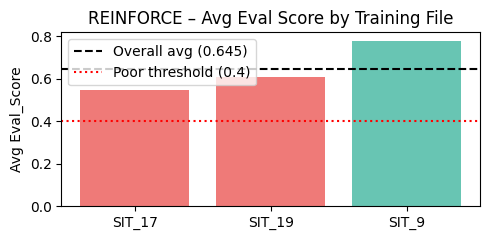

In [11]:
## Angle 2 — Training File
# Does a particular training file produce models that perform poorly across all test sets?

train_stats = rf_dedup.groupby("Training File")["Eval_Score"].agg(
    Avg_Score="mean",
    Poor_Count=lambda s: (s < POOR_THRESHOLD).sum(),
    Total="count"
).reset_index()
train_stats["Poor_Rate_%"] = (train_stats["Poor_Count"] / train_stats["Total"] * 100).round(1)
train_stats = train_stats.sort_values("Avg_Score")

train_overall_avg = rf_dedup["Eval_Score"].mean()
print(f"Overall REINFORCE Avg Eval_Score : {train_overall_avg:.4f}")
print()
print(train_stats.to_string(index=False))

# Training files whose avg score is below than overall average
poor_train = train_stats[train_stats["Avg_Score"] < train_overall_avg]["Training File"].tolist()
print(f"\n>>> Training files BELOW overall average ({train_overall_avg:.4f}): {poor_train}")

# Bar chart
fig, ax = plt.subplots(figsize=(5, 2.5))
colors = [RED if t in poor_train else GREEN for t in train_stats["Training File"]]
ax.bar(train_stats["Training File"], train_stats["Avg_Score"], color=colors)
ax.axhline(train_overall_avg, color="black", linestyle="--", label=f"Overall avg ({train_overall_avg:.3f})")
ax.axhline(POOR_THRESHOLD, color="red", linestyle=":", label=f"Poor threshold ({POOR_THRESHOLD})")
ax.set_ylabel("Avg Eval_Score"); ax.set_title("REINFORCE – Avg Eval Score by Training File")
ax.legend(); plt.tight_layout(); plt.show()


In [12]:
## Angle 2 — Model names with poor Eval_Score linked to each flagged training file

for train_file in poor_train:
    poor_models = rf_dedup[
        (rf_dedup["Training File"] == train_file) &
        (rf_dedup["Eval_Score"] < POOR_THRESHOLD)
    ][["Model File", "Attention Mechanism", "Test File", "Eval_Score"]].sort_values("Eval_Score")
    print(f"\n{'='*60}")
    print(f"Training File: {train_file}  |  {len(poor_models)} poor evaluations (score < {POOR_THRESHOLD})")
    print(f"{'='*60}")
    for _, row in poor_models.iterrows():
        print(f"  {row['Model File']}  |  attn={row['Attention Mechanism']}  test={row['Test File']}  score={row['Eval_Score']:.4f}")



Training File: SIT_17  |  7 poor evaluations (score < 0.4)
  REINFORCE_SA_SIT_17_500_1e-04_99_07-03-18-47  |  attn=Self-Attention  test=SIT_19  score=0.2617
  REINFORCE_TP_SIT_17_500_1e-04_99_07-03-18-47  |  attn=Temporal  test=SIT_19  score=0.2617
  REINFORCE_MH_SIT_17_500_1e-04_99_07-03-18-47  |  attn=Multi-Head  test=SIT_17  score=0.2619
  REINFORCE_SA_SIT_17_500_1e-04_99_07-03-18-47  |  attn=Self-Attention  test=SIT_17  score=0.2619
  REINFORCE_TP_SIT_17_500_1e-04_99_07-03-18-47  |  attn=Temporal  test=SIT_17  score=0.2619
  REINFORCE_SA_SIT_17_500_1e-04_99_07-03-18-47  |  attn=Self-Attention  test=SIT_9  score=0.2645
  REINFORCE_TP_SIT_17_500_1e-04_99_07-03-18-47  |  attn=Temporal  test=SIT_9  score=0.2645

Training File: SIT_19  |  6 poor evaluations (score < 0.4)
  REINFORCE_NW_SIT_19_500_1e-04_99_07-03-18-47  |  attn=Nadaraya-Watson  test=SIT_19  score=0.2617
  REINFORCE_TP_SIT_19_500_1e-04_99_07-03-18-47  |  attn=Temporal  test=SIT_19  score=0.2617
  REINFORCE_NW_SIT_19_500_1

## Angle 3 — Test File
- Identify Evalution files showing poor performance

Overall REINFORCE Avg Eval_Score : 0.6451

Test File  Avg_Score  Poor_Count  Total  Poor_Rate_%
   SIT_17   0.615945           6     12         50.0
    SIT_9   0.651165           5     12         41.7
   SIT_19   0.668060           5     12         41.7

>>> Test files BELOW overall average (0.6451): ['SIT_17']


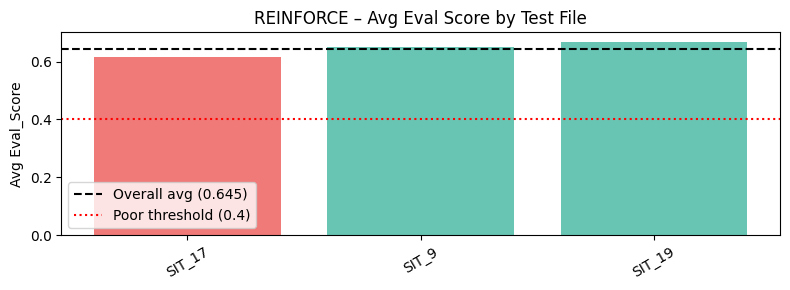

In [13]:
## Angle 3 — Test File
# Is it a specific test file that causes poor performance regardless of which model is evaluated?

test_stats = rf_dedup.groupby("Test File")["Eval_Score"].agg(
    Avg_Score="mean",
    Poor_Count=lambda s: (s < POOR_THRESHOLD).sum(),
    Total="count"
).reset_index()
test_stats["Poor_Rate_%"] = (test_stats["Poor_Count"] / test_stats["Total"] * 100).round(1)
test_stats = test_stats.sort_values("Avg_Score")

test_overall_avg = rf_dedup["Eval_Score"].mean()
print(f"Overall REINFORCE Avg Eval_Score : {test_overall_avg:.4f}")
print()
print(test_stats.to_string(index=False))

# Test files below overall average
poor_test = test_stats[test_stats["Avg_Score"] < test_overall_avg]["Test File"].tolist()
print(f"\n>>> Test files BELOW overall average ({test_overall_avg:.4f}): {poor_test}")

# Bar chart — sorted by score
fig, ax = plt.subplots(figsize=(8, 3))
colors = [RED if t in poor_test else GREEN for t in test_stats["Test File"]]
ax.bar(test_stats["Test File"], test_stats["Avg_Score"], color=colors)
ax.axhline(test_overall_avg, color="black", linestyle="--", label=f"Overall avg ({test_overall_avg:.3f})")
ax.axhline(POOR_THRESHOLD, color="red", linestyle=":", label=f"Poor threshold ({POOR_THRESHOLD})")
ax.set_ylabel("Avg Eval_Score"); ax.set_title("REINFORCE – Avg Eval Score by Test File")
ax.legend(); plt.xticks(rotation=30); plt.tight_layout(); plt.show()


In [14]:
## Angle 3 — Model names with poor Eval_Score linked to each flagged test file

for test_file in poor_test:
    poor_models = rf_dedup[
        (rf_dedup["Test File"] == test_file) &
        (rf_dedup["Eval_Score"] < POOR_THRESHOLD)
    ][["Model File", "Attention Mechanism", "Training File", "Eval_Score"]].sort_values("Eval_Score")
    print(f"\n{'='*60}")
    print(f"Test File: {test_file}  |  {len(poor_models)} poor evaluations (score < {POOR_THRESHOLD})")
    print(f"{'='*60}")
    for _, row in poor_models.iterrows():
        print(f"  {row['Model File']}  |  attn={row['Attention Mechanism']}  train={row['Training File']}  score={row['Eval_Score']:.4f}")



Test File: SIT_17  |  6 poor evaluations (score < 0.4)
  REINFORCE_MH_SIT_17_500_1e-04_99_07-03-18-47  |  attn=Multi-Head  train=SIT_17  score=0.2619
  REINFORCE_NW_SIT_19_500_1e-04_99_07-03-18-47  |  attn=Nadaraya-Watson  train=SIT_19  score=0.2619
  REINFORCE_SA_SIT_17_500_1e-04_99_07-03-18-47  |  attn=Self-Attention  train=SIT_17  score=0.2619
  REINFORCE_TP_SIT_17_500_1e-04_99_07-03-18-47  |  attn=Temporal  train=SIT_17  score=0.2619
  REINFORCE_TP_SIT_19_500_1e-04_99_07-03-18-47  |  attn=Temporal  train=SIT_19  score=0.2619
  REINFORCE_TP_SIT_9_500_1e-04_99_07-03-18-47  |  attn=Temporal  train=SIT_9  score=0.2619


## TOOL WEAR Plots

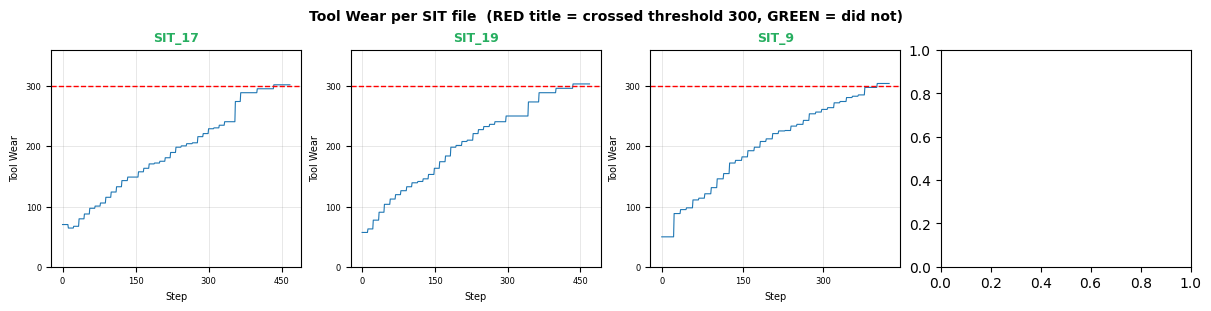

In [ ]:
## Tool Wear Grid — SIT dataset
# Plots tool_wear vs time for every file in ../data/SIT
# Threshold line at 300; title coloured RED if crossed, GREEN if not.

import glob, os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

DATA_DIR  = "../data/SIT"
THRESHOLD = 300

files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
n     = len(files)
ncols = 4
nrows = -(-n // ncols)   # ceiling division

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 3, nrows * 3),
                         constrained_layout=True)
axes = axes.flat

for ax, fpath in zip(axes, files):
    label   = os.path.splitext(os.path.basename(fpath))[0]
    tw      = pd.read_csv(fpath)["tool_wear"]
    crossed = tw.max() >= THRESHOLD

    ax.plot(tw, color="#1f77b4", linewidth=0.8)
    ax.axhline(THRESHOLD, color="red", linestyle="--", linewidth=1.0)
    ax.set_title(label, fontsize=9,
                 color="#27ae60" if crossed else "#c0392b",
                 fontweight="bold")
    ax.set_ylim(0, THRESHOLD*1.2)
    ax.set_xlabel("Step", fontsize=7)
    ax.set_ylabel("Tool Wear", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(4))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(4))
    ax.grid(True, color="grey", alpha=0.25, linewidth=0.5)

for ax in list(axes)[n:]:
    ax.set_visible(False)

fig.suptitle("Tool Wear per SIT file  (RED title = crossed threshold 300, GREEN = did not)",
             fontsize=10, fontweight="bold")
plt.show()


## Extend non-crossing files so tool_wear crosses threshold

- Strategy: find the last stair-step period, repeat it with tool_wear incremented by one median step each cycle, until we clear THRESHOLD.

Files that did NOT cross 300: ['SIT_17.csv', 'SIT_19.csv', 'SIT_9.csv']
  SIT_17.csv    original=400 rows  extended=468 rows  new_max=302.19
  SIT_19.csv    original=400 rows  extended=470 rows  new_max=303.63
  SIT_9.csv     original=400 rows  extended=423 rows  new_max=304.38


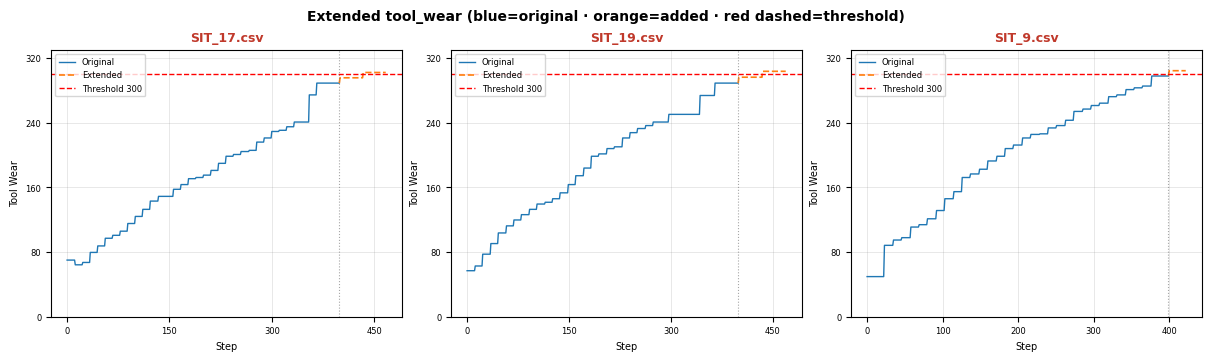

In [28]:
## Extend non-crossing files so tool_wear crosses threshold
# Strategy: find the last stair-step period, repeat it with tool_wear
# incremented by one median step each cycle, until we clear THRESHOLD.

import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

DATA_DIR  = "../data/SIT"
THRESHOLD = 300

files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))

# ── identify non-crossing files ───────────────────────────────────────
non_crossing = []
for fpath in files:
    df_raw = pd.read_csv(fpath)
    if df_raw["tool_wear"].max() < THRESHOLD:
        non_crossing.append(fpath)

print(f"Files that did NOT cross {THRESHOLD}: {[os.path.basename(f) for f in non_crossing]}")

# ── extend each file in memory ────────────────────────────────────────
extended_data = {}   # label -> (original_len, full_df)

for fpath in non_crossing:
    df_raw  = pd.read_csv(fpath).reset_index(drop=True)
    tw      = df_raw["tool_wear"]

    # median positive step size
    diffs     = tw.diff().dropna()
    step_size = diffs[diffs > 0].median()

    # length of one stair tread: rows where tool_wear equals the last value
    last_val   = tw.iloc[-1]
    tread_mask = tw == last_val
    # find the start of the last tread
    tread_start = tread_mask[::-1].idxmin()   # first False counting from end
    if not tread_mask.iloc[0]:                # guard: whole series isn't flat
        tread_start = tread_start + 1
    else:
        tread_start = 0
    tread_period = len(df_raw) - tread_start

    # build extension: repeat the tread block, raising tool_wear each repeat
    chunks   = [df_raw]
    cur_base = last_val
    while cur_base < THRESHOLD:
        cur_base += step_size
        block = df_raw.iloc[-tread_period:].copy()
        block["tool_wear"] = round(cur_base, 4)
        chunks.append(block)

    df_ext = pd.concat(chunks, ignore_index=True)
    orig_len = len(df_raw)
    extended_data[os.path.basename(fpath)] = (orig_len, df_ext)
    print(f"  {os.path.basename(fpath):12s}  original={orig_len} rows  "
          f"extended={len(df_ext)} rows  new_max={df_ext['tool_wear'].max():.2f}")

# ── plot ──────────────────────────────────────────────────────────────
n     = len(non_crossing)
ncols = min(n, 3)
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 4, nrows * 3.5),
                         constrained_layout=True)
axes_flat = np.array(axes).flat if n > 1 else [axes]

for ax, (label, (orig_len, df_ext)) in zip(axes_flat, extended_data.items()):
    tw_all = df_ext["tool_wear"]

    # original part in blue, appended part in orange
    ax.plot(range(orig_len),        tw_all[:orig_len],  color="#1f77b4", linewidth=1.0, label="Original")
    ax.plot(range(orig_len - 1, len(df_ext)), tw_all[orig_len - 1:],
            color="#ff7f0e", linewidth=1.2, linestyle="--", label="Extended")

    ax.axvline(orig_len - 1, color="grey", linestyle=":", linewidth=0.8, alpha=0.7)
    ax.axhline(THRESHOLD, color="red", linestyle="--", linewidth=1.0, label=f"Threshold {THRESHOLD}")

    ax.set_ylim(0, THRESHOLD + 30)
    ax.set_title(label, fontsize=9, color="#c0392b", fontweight="bold")
    ax.set_xlabel("Step", fontsize=7)
    ax.set_ylabel("Tool Wear", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(5))
    ax.grid(True, color="grey", alpha=0.25, linewidth=0.5)
    ax.legend(fontsize=6, loc="upper left")

for ax in list(axes_flat)[n:]:
    ax.set_visible(False)

fig.suptitle("Extended tool_wear (blue=original · orange=added · red dashed=threshold)",
             fontsize=10, fontweight="bold")
plt.show()


In [29]:
## ── Save extended files ──────────────────────────────────────────────
# Set CONFIRM = True once you are happy with the extended data above,
# then run this cell to write copies into ../data/SIT_Extended/

CONFIRM = True          # <── change to True to actually write files
OUT_DIR = "../data/SIT_Extended"

if not CONFIRM:
    print("Nothing saved.  Set CONFIRM = True and re-run this cell to save copies.")
else:
    os.makedirs(OUT_DIR, exist_ok=True)
    for label, (orig_len, df_ext) in extended_data.items():
        out_path = os.path.join(OUT_DIR, label)
        df_ext.to_csv(out_path, index=False)
        print(f"  Saved -> {out_path}  ({len(df_ext)} rows)")
    print(f"\nDone. {len(extended_data)} file(s) written to '{OUT_DIR}'")


  Saved -> ../data/SIT_Extended/SIT_17.csv  (468 rows)
  Saved -> ../data/SIT_Extended/SIT_19.csv  (470 rows)
  Saved -> ../data/SIT_Extended/SIT_9.csv  (423 rows)

Done. 3 file(s) written to '../data/SIT_Extended'


## Tool-wear plot utility

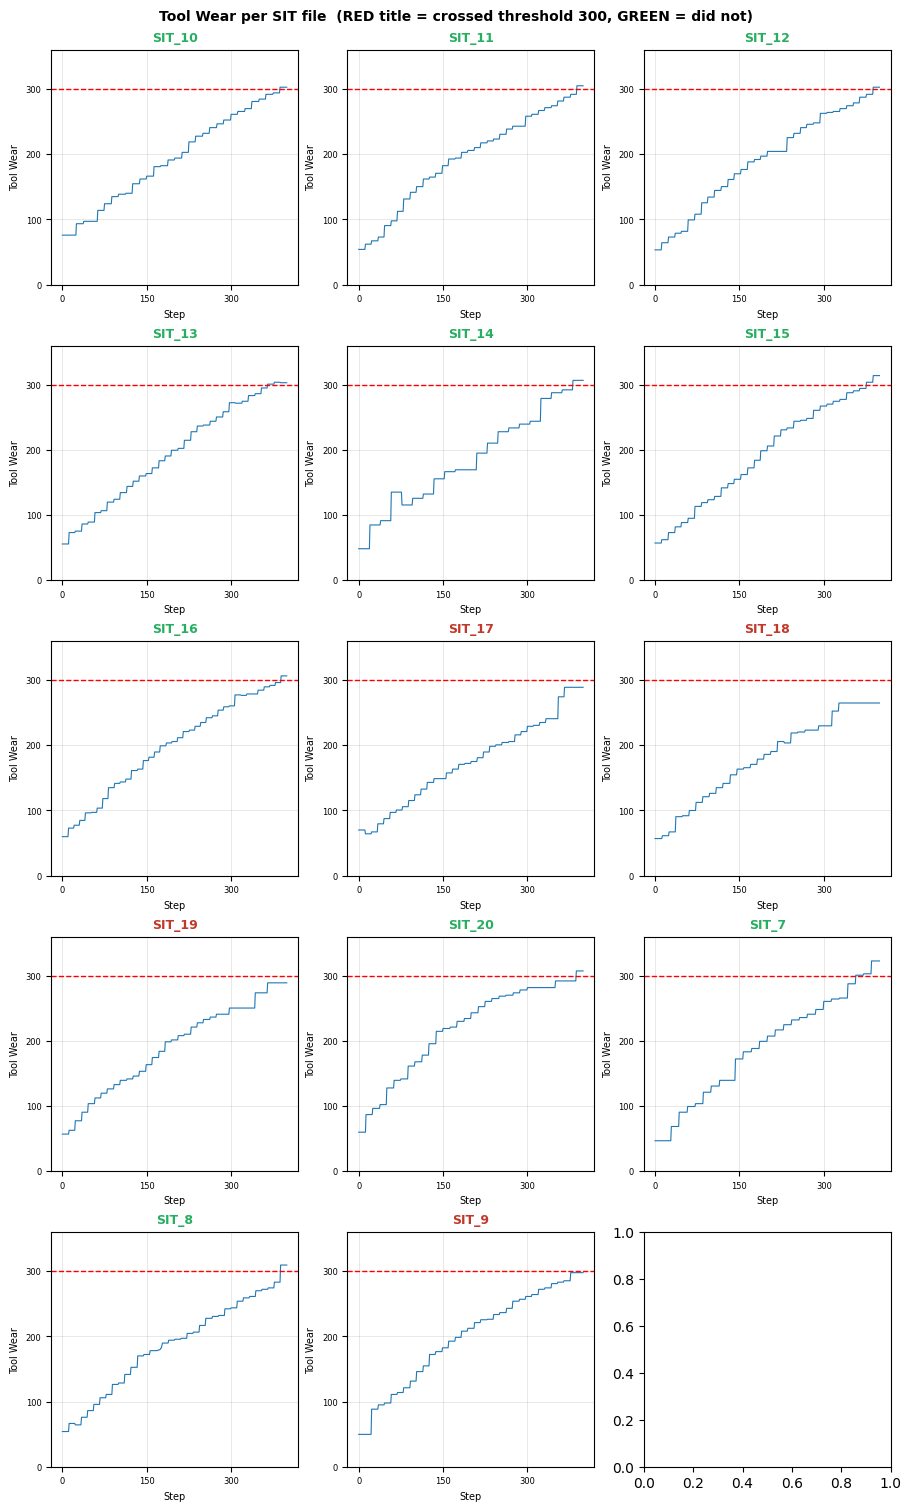

In [3]:
import glob, os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

DATA_DIR  = "../data/Original_SIT_data"
THRESHOLD = 300

files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
n     = len(files)
ncols = 3
nrows = -(-n // ncols)   # ceiling division

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 3, nrows * 3),
                         constrained_layout=True)
axes = axes.flat

for ax, fpath in zip(axes, files):
    label   = os.path.splitext(os.path.basename(fpath))[0]
    tw      = pd.read_csv(fpath)["tool_wear"]
    crossed = tw.max() >= THRESHOLD

    ax.plot(tw, color="#1f77b4", linewidth=0.8)
    ax.axhline(THRESHOLD, color="red", linestyle="--", linewidth=1.0)
    ax.set_title(label, fontsize=9,
                 color="#27ae60" if crossed else "#c0392b",
                 fontweight="bold")
    ax.set_ylim(0, THRESHOLD*1.2)
    ax.set_xlabel("Step", fontsize=7)
    ax.set_ylabel("Tool Wear", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(4))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(4))
    ax.grid(True, color="grey", alpha=0.25, linewidth=0.5)

for ax in list(axes)[n:]:
    ax.set_visible(False)

fig.suptitle("Tool Wear per SIT file  (RED title = crossed threshold 300, GREEN = did not)",
             fontsize=10, fontweight="bold")
plt.show()
